In [1]:
import pandas as pd

file_path = "../data/raw/E-Commerce Customer Insights and Churn Dataset3938d09.xls"

df = pd.read_excel(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (2000, 16)

Columns:
['order_id', 'customer_id', 'age', 'gender', 'product_id', 'country', 'signup_date', 'last_purchase_date', 'cancellations_count', 'subscription_status', 'unit_price', 'quantity', 'purchase_frequency', 'product_name', 'category', 'Ratings']


,order_id,customer_id,age,gender,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,unit_price,quantity,purchase_frequency,product_name,category,Ratings
0,ORD5000,CUST1000,39,Female,PROD200,Canada,2021-07-01 00:00:00,2/21/2023,0,active,78.21,5,37,Football,Sports,4.2
1,ORD5001,CUST1001,61,Female,PROD201,USA,10/19/2020,2021-08-12 00:00:00,0,active,64.02,8,35,Refrigerator,Home,4.0
2,ORD5002,CUST1002,26,Female,PROD202,Pakistan,2023-10-06 00:00:00,2023-04-09 00:00:00,3,cancelled,604.14,2,44,Hoodie,Clothing,3.9
3,ORD5003,CUST1003,54,Male,PROD203,India,7/30/2023,2/20/2024,4,paused,84.66,4,1,Conditioner,Beauty,4.2
4,ORD5004,CUST1004,50,Male,PROD204,India,2020-09-12 00:00:00,9/14/2024,0,active,62.66,7,35,Smartwatch,Electronics,4.2


In [3]:
print("Data Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Convert date columns to proper datetime format
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

df["last_purchase_date"] = pd.to_datetime(
    df["last_purchase_date"],
    errors="coerce"
)

print("\nDate Range:")

print(
    "Signup:",
    df["signup_date"].min(),
    "to",
    df["signup_date"].max()
)

print(
    "Last Purchase:",
    df["last_purchase_date"].min(),
    "to",
    df["last_purchase_date"].max()
)

Data Types:


order_id                object
customer_id             object
age                      int64
gender                  object
product_id              object
country                 object
signup_date             object
last_purchase_date      object
cancellations_count      int64
subscription_status     object
unit_price             float64
quantity                 int64
purchase_frequency       int64
product_name            object
category                object
Ratings                float64
dtype: object


Missing Values:


order_id               0
customer_id            0
age                    0
gender                 0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
unit_price             0
quantity               0
purchase_frequency     0
product_name           0
category               0
Ratings                0
dtype: int64


Duplicate Rows: 0

Date Range:
Signup: 2020-01-09 00:00:00 to 2023-12-08 00:00:00
Last Purchase: 2020-07-11 00:00:00 to 2025-12-08 00:00:00


In [4]:
# Create revenue column
df["revenue"] = df["unit_price"] * df["quantity"]

# Aggregate revenue by last purchase date
daily_sales = (
    df.groupby("last_purchase_date")["revenue"]
      .sum()
      .sort_index()
)

print("Number of unique purchase dates:", daily_sales.index.nunique())

print("\nFirst 10 dates:")
display(daily_sales.head(10))

print("\nLast 10 dates:")
display(daily_sales.tail(10))

print("\nRevenue statistics:")
display(daily_sales.describe())

Number of unique purchase dates: 1078

First 10 dates:


last_purchase_date
2020-07-11    1884.12
2020-09-11     647.50
2020-09-20    1033.48
2020-10-11     603.87
2020-10-17     248.17
2020-12-22    1361.28
2021-01-04     120.40
2021-01-06    1642.77
2021-01-17    1181.72
2021-01-24     629.40
Name: revenue, dtype: float64


Last 10 dates:


last_purchase_date
2025-11-02    3282.26
2025-11-03     240.94
2025-11-04     940.80
2025-11-06     418.72
2025-12-01     123.64
2025-12-03    3307.03
2025-12-04    1086.93
2025-12-06    3373.38
2025-12-07    2823.28
2025-12-08    1529.00
Name: revenue, dtype: float64


Revenue statistics:


count    1078.000000
mean     1903.238080
std      1302.072167
min        22.290000
25%       936.642500
50%      1623.160000
75%      2748.540000
max      7373.330000
Name: revenue, dtype: float64

In [5]:
# Create monthly sales data
monthly_sales = (
    df.set_index("last_purchase_date")
      .resample("MS")["revenue"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["date", "sales"]

print("Number of months:", len(monthly_sales))

display(monthly_sales.head(10))
display(monthly_sales.tail(10))

Number of months: 66


,date,sales
0,2020-07-01,1884.12
1,2020-08-01,0.00
2,2020-09-01,1680.98
3,2020-10-01,852.04
4,2020-11-01,0.00
5,2020-12-01,1361.28
6,2021-01-01,6545.18
7,2021-02-01,7883.57
8,2021-03-01,8404.88
9,2021-04-01,12455.00


,date,sales
56,2025-03-01,43259.52
57,2025-04-01,45637.73
58,2025-05-01,49251.89
59,2025-06-01,39969.87
60,2025-07-01,61060.38
61,2025-08-01,32929.72
62,2025-09-01,20276.55
63,2025-10-01,14120.47
64,2025-11-01,9580.18
65,2025-12-01,12243.26


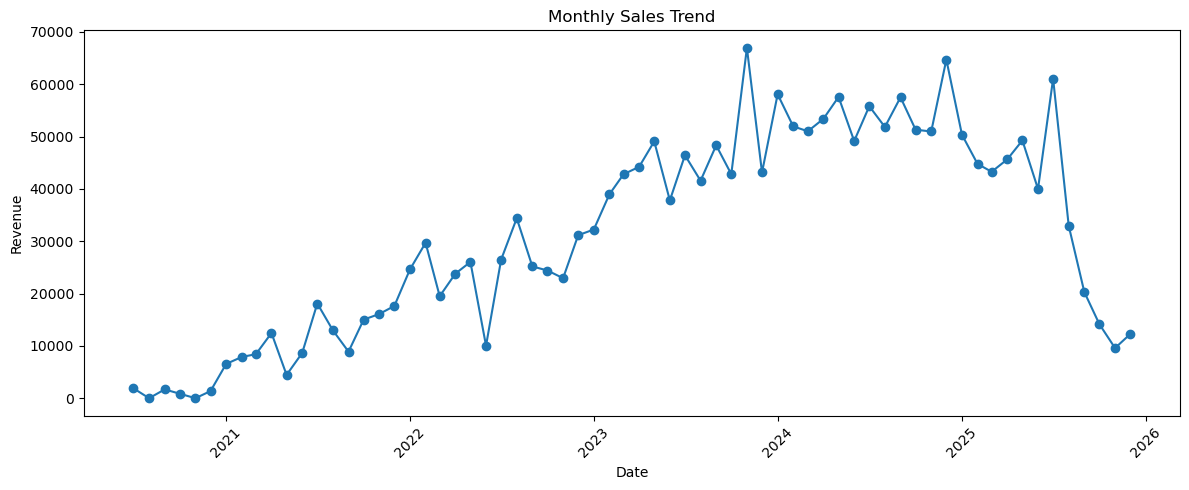

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Extract calendar features
monthly_sales["year"] = monthly_sales["date"].dt.year
monthly_sales["month"] = monthly_sales["date"].dt.month

print("Average sales by month:")
display(
    monthly_sales.groupby("month")["sales"]
    .mean()
    .round(2)
)

Average sales by month:


month
1     34357.74
2     34644.36
3     32984.41
4     35894.00
5     37272.46
6     29115.34
7     34953.30
8     28940.35
9     26970.93
10    24745.98
11    27748.89
12    28365.39
Name: sales, dtype: float64

In [8]:
print("Total sales by year:")

yearly_sales = (
    monthly_sales.groupby("year")["sales"]
    .sum()
    .round(2)
)

display(yearly_sales)

Total sales by year:


year
2020      5778.42
2021    137047.34
2022    298131.90
2023    534180.89
2024    653124.91
2025    423427.19
Name: sales, dtype: float64

In [9]:
# Train/Test split
train = monthly_sales.iloc[:-12].copy()
test = monthly_sales.iloc[-12:].copy()

print("Training period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

print("\nTrain months:", len(train))
print("Test months:", len(test))

Training period:
2020-07-01 00:00:00 to 2024-12-01 00:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-01 00:00:00

Train months: 54
Test months: 12


In [10]:
from prophet import Prophet

# Prophet requires columns named ds and y
prophet_train = train[["date", "sales"]].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

prophet_test = test[["date", "sales"]].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

print(prophet_train.head())

ModuleNotFoundError: No module named 'prophet'

In [11]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_train)

print("Prophet model trained successfully.")

NameError: name 'Prophet' is not defined

In [12]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_train)

print("Prophet model trained successfully.")

ModuleNotFoundError: No module named 'prophet'

In [1]:
from prophet import Prophet

print("Prophet imported successfully")

Prophet imported successfully


In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_train)

print("Prophet model trained successfully.")

In [ ]:
prophet_train = train[["date", "sales"]].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

prophet_test = test[["date", "sales"]].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

print(prophet_train.head())

In [6]:
import pandas as pd

file_path = "../data/raw/E-Commerce Customer Insights and Churn Dataset3938d09.xls"

df = pd.read_excel(file_path)

df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")
df["last_purchase_date"] = pd.to_datetime(
    df["last_purchase_date"],
    errors="coerce"
)

df["revenue"] = df["unit_price"] * df["quantity"]

monthly_sales = (
    df.set_index("last_purchase_date")
      .resample("MS")["revenue"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["date", "sales"]

print("Monthly records:", len(monthly_sales))

Monthly records: 66


In [7]:
train = monthly_sales.iloc[:-12].copy()
test = monthly_sales.iloc[-12:].copy()

print("Train months:", len(train))
print("Test months:", len(test))

Train months: 54
Test months: 12


In [8]:
from prophet import Prophet

prophet_train = train[["date", "sales"]].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

prophet_test = test[["date", "sales"]].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

print(prophet_train.head())

          ds        y
0 2020-07-01  1884.12
1 2020-08-01     0.00
2 2020-09-01  1680.98
3 2020-10-01   852.04
4 2020-11-01     0.00


In [9]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_train)

print("Prophet model trained successfully.")

18:21:04 - cmdstanpy - INFO - Chain [1] start processing
18:21:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


In [10]:
forecast_test = model.predict(
    prophet_test[["ds"]]
)

# Keep only the columns we need
predictions = forecast_test[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].copy()

predictions["actual"] = prophet_test["y"].values

display(predictions)

,ds,yhat,yhat_lower,yhat_upper,actual
0,2025-01-01,67130.538808,61764.724795,72315.428467,50342.16
1,2025-02-01,71734.271296,66548.309715,77022.085984,44755.46
2,2025-03-01,66968.799640,61560.045240,72118.144950,43259.52
3,2025-04-01,70054.994198,64616.465930,75873.074498,45637.73
4,2025-05-01,70310.935873,64973.838654,75907.218164,49251.89
5,2025-06-01,63962.544752,58693.885032,69751.743044,39969.87
6,2025-07-01,74144.376522,68524.114008,79608.034287,61060.38
7,2025-08-01,72436.274240,67370.594014,77853.311250,32929.72
8,2025-09-01,72742.233075,67326.350533,78424.964734,20276.55
9,2025-10-01,71372.767654,66151.119984,76820.419258,14120.47


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = predictions["actual"]
predicted = predictions["yhat"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

# MAPE excluding zero actual values
non_zero = actual != 0
mape = np.mean(
    np.abs(
        (actual[non_zero] - predicted[non_zero])
        / actual[non_zero]
    )
) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  35712.21
RMSE: 40112.59
MAPE: 192.84%


In [12]:
forecast_data = monthly_sales[["date", "sales"]].copy()

forecast_data["lag_1"] = forecast_data["sales"].shift(1)
forecast_data["lag_2"] = forecast_data["sales"].shift(2)
forecast_data["lag_3"] = forecast_data["sales"].shift(3)
forecast_data["lag_6"] = forecast_data["sales"].shift(6)

forecast_data["rolling_3"] = (
    forecast_data["sales"]
    .shift(1)
    .rolling(3)
    .mean()
)

forecast_data["rolling_6"] = (
    forecast_data["sales"]
    .shift(1)
    .rolling(6)
    .mean()
)

forecast_data["month"] = forecast_data["date"].dt.month
forecast_data["year"] = forecast_data["date"].dt.year

display(forecast_data.head(10))

,date,sales,lag_1,lag_2,lag_3,lag_6,rolling_3,rolling_6,month,year
0,2020-07-01,1884.12,NaN,NaN,NaN,NaN,NaN,NaN,7,2020
1,2020-08-01,0.00,1884.12,NaN,NaN,NaN,NaN,NaN,8,2020
2,2020-09-01,1680.98,0.00,1884.12,NaN,NaN,NaN,NaN,9,2020
3,2020-10-01,852.04,1680.98,0.00,1884.12,NaN,1188.366667,NaN,10,2020
4,2020-11-01,0.00,852.04,1680.98,0.00,NaN,844.340000,NaN,11,2020
5,2020-12-01,1361.28,0.00,852.04,1680.98,NaN,844.340000,NaN,12,2020
6,2021-01-01,6545.18,1361.28,0.00,852.04,1884.12,737.773333,963.070000,1,2021
7,2021-02-01,7883.57,6545.18,1361.28,0.00,0.00,2635.486667,1739.913333,2,2021
8,2021-03-01,8404.88,7883.57,6545.18,1361.28,1680.98,5263.343333,3053.841667,3,2021
9,2021-04-01,12455.00,8404.88,7883.57,6545.18,852.04,7611.210000,4174.491667,4,2021


In [13]:
forecast_data = forecast_data.dropna().reset_index(drop=True)

print("Rows after removing NaN:", len(forecast_data))

display(forecast_data.head())

Rows after removing NaN: 60


,date,sales,lag_1,lag_2,lag_3,lag_6,rolling_3,rolling_6,month,year
0,2021-01-01,6545.18,1361.28,0.00,852.04,1884.12,737.773333,963.070000,1,2021
1,2021-02-01,7883.57,6545.18,1361.28,0.00,0.00,2635.486667,1739.913333,2,2021
2,2021-03-01,8404.88,7883.57,6545.18,1361.28,1680.98,5263.343333,3053.841667,3,2021
3,2021-04-01,12455.00,8404.88,7883.57,6545.18,852.04,7611.210000,4174.491667,4,2021
4,2021-05-01,4449.74,12455.00,8404.88,7883.57,0.00,9581.150000,6108.318333,5,2021


In [14]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_3",
    "rolling_6",
    "month",
    "year"
]

X = forecast_data[features]
y = forecast_data["sales"]

# Last 12 months for testing
X_train = X.iloc[:-12]
X_test = X.iloc[-12:]

y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 48
Testing rows: 12


In [15]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [16]:
xgb_predictions = xgb_model.predict(X_test)

xgb_results = test[["date", "sales"]].copy()
xgb_results["predicted_sales"] = xgb_predictions

display(xgb_results)

,date,sales,predicted_sales
54,2025-01-01,50342.16,51254.375000
55,2025-02-01,44755.46,53510.656250
56,2025-03-01,43259.52,59779.875000
57,2025-04-01,45637.73,58646.273438
58,2025-05-01,49251.89,61212.031250
59,2025-06-01,39969.87,53803.492188
60,2025-07-01,61060.38,60982.523438
61,2025-08-01,32929.72,43196.714844
62,2025-09-01,20276.55,46875.761719
63,2025-10-01,14120.47,38618.476562


In [17]:
actual = xgb_results["sales"]
predicted = xgb_results["predicted_sales"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

non_zero = actual != 0

mape = np.mean(
    np.abs(
        (actual[non_zero] - predicted[non_zero])
        / actual[non_zero]
    )
) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  13957.03
RMSE: 16401.21
MAPE: 73.53%


In [18]:
future_dates = pd.date_range(
    start="2026-01-01",
    periods=12,
    freq="MS"
)

future_forecast = pd.DataFrame({
    "date": future_dates
})

display(future_forecast)

,date
0,2026-01-01
1,2026-02-01
2,2026-03-01
3,2026-04-01
4,2026-05-01
5,2026-06-01
6,2026-07-01
7,2026-08-01
8,2026-09-01
9,2026-10-01


In [19]:
history = monthly_sales[["date", "sales"]].copy()

future_predictions = []

for current_date in future_forecast["date"]:

    sales_history = history["sales"]

    features = pd.DataFrame([{
        "lag_1": sales_history.iloc[-1],
        "lag_2": sales_history.iloc[-2],
        "lag_3": sales_history.iloc[-3],
        "lag_6": sales_history.iloc[-6],
        "rolling_3": sales_history.iloc[-3:].mean(),
        "rolling_6": sales_history.iloc[-6:].mean(),
        "month": current_date.month,
        "year": current_date.year
    }])

    prediction = xgb_model.predict(features)[0]

    future_predictions.append(prediction)

    # Add prediction to history for the next iteration
    history = pd.concat([
        history,
        pd.DataFrame({
            "date": [current_date],
            "sales": [prediction]
        })
    ], ignore_index=True)

future_forecast["predicted_sales"] = future_predictions

display(future_forecast)

,date,predicted_sales
0,2026-01-01,27405.953125
1,2026-02-01,31162.544922
2,2026-03-01,23816.361328
3,2026-04-01,28506.458984
4,2026-05-01,25699.341797
5,2026-06-01,22385.765625
6,2026-07-01,27715.527344
7,2026-08-01,31613.324219
8,2026-09-01,20976.013672
9,2026-10-01,28445.433594


In [20]:
total_2026_sales = future_forecast["predicted_sales"].sum()

highest_month = future_forecast.loc[
    future_forecast["predicted_sales"].idxmax()
]

lowest_month = future_forecast.loc[
    future_forecast["predicted_sales"].idxmin()
]

print(f"Predicted total sales for 2026: {total_2026_sales:,.2f}")

print(
    f"\nHighest predicted month: "
    f"{highest_month['date'].strftime('%B %Y')} "
    f"({highest_month['predicted_sales']:,.2f})"
)

print(
    f"Lowest predicted month: "
    f"{lowest_month['date'].strftime('%B %Y')} "
    f"({lowest_month['predicted_sales']:,.2f})"
)

Predicted total sales for 2026: 313,466.72

Highest predicted month: August 2026 (31,613.32)
Lowest predicted month: December 2026 (19,603.26)


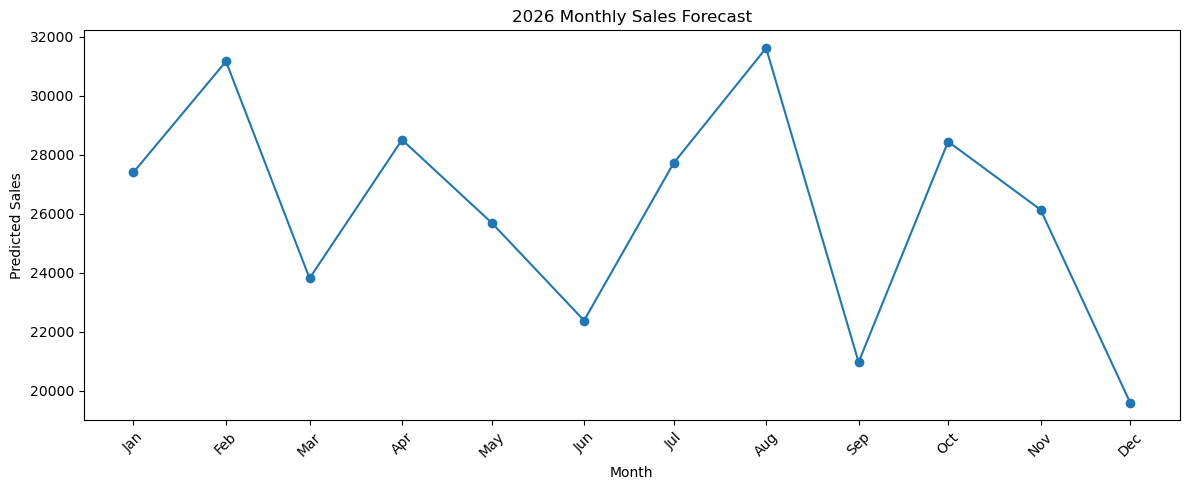

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    future_forecast["date"],
    future_forecast["predicted_sales"],
    marker="o"
)

plt.title("2026 Monthly Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.xticks(
    future_forecast["date"],
    future_forecast["date"].dt.strftime("%b"),
    rotation=45
)

plt.tight_layout()
plt.show()

In [22]:
print("Unique products:", df["product_id"].nunique())
print("Unique product names:", df["product_name"].nunique())
print("Unique categories:", df["category"].nunique())

display(
    df[["product_id", "product_name", "category"]]
    .drop_duplicates()
    .head(20)
)

Unique products: 2000
Unique product names: 40
Unique categories: 5


,product_id,product_name,category
0,PROD200,Football,Sports
1,PROD201,Refrigerator,Home
2,PROD202,Hoodie,Clothing
3,PROD203,Conditioner,Beauty
4,PROD204,Smartwatch,Electronics
5,PROD205,Hoodie,Clothing
6,PROD206,Tablet,Electronics
7,PROD207,Jacket,Clothing
8,PROD208,Nail Polish,Beauty
9,PROD209,Camera,Electronics


In [23]:
product_summary = (
    df.groupby(["product_id", "product_name", "category"])
      .agg(
          transactions=("order_id", "count"),
          total_quantity=("quantity", "sum"),
          total_revenue=("revenue", "sum")
      )
      .reset_index()
      .sort_values("transactions", ascending=False)
)

print("Number of unique products:", len(product_summary))

display(product_summary.head(20))

Number of unique products: 2000


,product_id,product_name,category,transactions,total_quantity,total_revenue
0,PROD1000,Smartphone,Electronics,1,6,1652.22
1329,PROD329,Shampoo,Beauty,1,3,510.81
1342,PROD342,T-Shirt,Clothing,1,4,710.88
1341,PROD341,Sneakers,Clothing,1,8,1749.76
1340,PROD340,Cycling Helmet,Sports,1,7,1259.02
1339,PROD339,Sneakers,Clothing,1,9,1375.02
1338,PROD338,Cycling Helmet,Sports,1,5,759.80
1337,PROD337,Headphones,Electronics,1,9,49.32
1336,PROD336,Face Wash,Beauty,1,7,722.82
1335,PROD335,Microwave,Home,1,7,782.46


In [24]:
product_frequency = (
    df.groupby("product_name")
      .agg(
          transactions=("order_id", "count"),
          total_quantity=("quantity", "sum"),
          total_revenue=("revenue", "sum")
      )
      .reset_index()
      .sort_values("transactions", ascending=False)
)

print("Unique product names:", len(product_frequency))

display(product_frequency)

Unique product names: 40


,product_name,transactions,total_quantity,total_revenue
33,Sneakers,72,384,75622.14
30,Skirt,64,293,69781.61
10,Dumbbells,62,293,66956.52
25,Perfume,61,314,56164.26
29,Shirt,61,328,57910.03
32,Smartwatch,58,266,52660.42
31,Smartphone,57,263,58772.23
6,Cricket Bat,57,299,57986.18
3,Camera,56,275,55719.73
21,Lipstick,56,277,58218.68


In [25]:
product_monthly = (
    df.set_index("last_purchase_date")
      .groupby("product_name")["revenue"]
      .resample("MS")
      .sum()
      .reset_index()
)

product_monthly.columns = [
    "product_name",
    "date",
    "sales"
]

print("Product-month records:", len(product_monthly))

display(product_monthly.head(15))

Product-month records: 2204


,product_name,date,sales
0,Basketball,2021-01-01,1642.77
1,Basketball,2021-02-01,0.00
2,Basketball,2021-03-01,1358.91
3,Basketball,2021-04-01,0.00
4,Basketball,2021-05-01,248.80
5,Basketball,2021-06-01,3384.08
6,Basketball,2021-07-01,0.00
7,Basketball,2021-08-01,0.00
8,Basketball,2021-09-01,510.48
9,Basketball,2021-10-01,0.00


In [26]:
product_monthly = product_monthly.sort_values(
    ["product_name", "date"]
).copy()

product_monthly["lag_1"] = (
    product_monthly.groupby("product_name")["sales"].shift(1)
)

product_monthly["lag_3"] = (
    product_monthly.groupby("product_name")["sales"].shift(3)
)

product_monthly["lag_6"] = (
    product_monthly.groupby("product_name")["sales"].shift(6)
)

product_monthly["rolling_3"] = (
    product_monthly.groupby("product_name")["sales"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

product_monthly["rolling_6"] = (
    product_monthly.groupby("product_name")["sales"]
    .transform(lambda x: x.shift(1).rolling(6).mean())
)

product_monthly["month"] = product_monthly["date"].dt.month
product_monthly["year"] = product_monthly["date"].dt.year

product_monthly = product_monthly.dropna().reset_index(drop=True)

print("Rows:", len(product_monthly))

display(product_monthly.head(15))

Rows: 1964


,product_name,date,sales,lag_1,lag_3,lag_6,rolling_3,rolling_6,month,year
0,Basketball,2021-07-01,0.00,3384.08,0.00,1642.77,1210.960000,1105.760000,7,2021
1,Basketball,2021-08-01,0.00,0.00,248.80,0.00,1210.960000,831.965000,8,2021
2,Basketball,2021-09-01,510.48,0.00,3384.08,1358.91,1128.026667,831.965000,9,2021
3,Basketball,2021-10-01,0.00,510.48,0.00,0.00,170.160000,690.560000,10,2021
4,Basketball,2021-11-01,1976.22,0.00,0.00,248.80,170.160000,690.560000,11,2021
5,Basketball,2021-12-01,0.00,1976.22,510.48,3384.08,828.900000,978.463333,12,2021
6,Basketball,2022-01-01,0.00,0.00,0.00,0.00,658.740000,414.450000,1,2022
7,Basketball,2022-02-01,3253.86,0.00,1976.22,0.00,658.740000,414.450000,2,2022
8,Basketball,2022-03-01,103.66,3253.86,0.00,510.48,1084.620000,956.760000,3,2022
9,Basketball,2022-04-01,0.00,103.66,0.00,0.00,1119.173333,888.956667,4,2022


In [27]:
product_counts = (
    product_monthly.groupby("product_name")
    .agg(
        months=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .reset_index()
)

print("Number of products:", len(product_counts))
print("\nMinimum months for a product:", product_counts["months"].min())
print("Maximum months for a product:", product_counts["months"].max())

display(product_counts.sort_values("months").head(10))

Number of products: 40

Minimum months for a product: 43
Maximum months for a product: 60


,product_name,months,first_date,last_date
13,Foundation,43,2022-05-01,2025-11-01
36,Tablet,44,2022-05-01,2025-12-01
6,Cricket Bat,44,2022-01-01,2025-08-01
37,Tennis Racket,45,2022-03-01,2025-11-01
3,Camera,45,2022-04-01,2025-12-01
34,Sofa,46,2022-01-01,2025-10-01
5,Conditioner,46,2022-01-01,2025-10-01
8,Dining Table,46,2022-03-01,2025-12-01
35,T-Shirt,46,2021-10-01,2025-07-01
22,Microwave,47,2021-12-01,2025-10-01


In [28]:
train_parts = []
test_parts = []

for product, group in product_monthly.groupby("product_name"):
    group = group.sort_values("date").reset_index(drop=True)

    train_parts.append(group.iloc[:-12])
    test_parts.append(group.iloc[-12:])

product_train = pd.concat(train_parts, ignore_index=True)
product_test = pd.concat(test_parts, ignore_index=True)

print("Training rows:", len(product_train))
print("Testing rows:", len(product_test))

print("\nTest period:")
print(product_test["date"].min(), "to", product_test["date"].max())

display(product_test.head(10))

Training rows: 1484
Testing rows: 480

Test period:
2024-07-01 00:00:00 to 2025-12-01 00:00:00


,product_name,date,sales,lag_1,lag_3,lag_6,rolling_3,rolling_6,month,year
0,Basketball,2024-09-01,4178.62,0.00,0.00,0.00,164.980000,82.490000,9,2024
1,Basketball,2024-10-01,935.95,4178.62,494.94,0.00,1557.853333,778.926667,10,2024
2,Basketball,2024-11-01,1033.80,935.95,0.00,0.00,1704.856667,934.918333,11,2024
3,Basketball,2024-12-01,1228.83,1033.80,4178.62,0.00,2049.456667,1107.218333,12,2024
4,Basketball,2025-01-01,0.00,1228.83,935.95,494.94,1066.193333,1312.023333,1,2025
5,Basketball,2025-02-01,1786.68,0.00,1033.80,0.00,754.210000,1229.533333,2,2025
6,Basketball,2025-03-01,536.52,1786.68,1228.83,4178.62,1005.170000,1527.313333,3,2025
7,Basketball,2025-04-01,0.00,536.52,0.00,935.95,774.400000,920.296667,4,2025
8,Basketball,2025-05-01,1095.60,0.00,1786.68,1033.80,774.400000,764.305000,5,2025
9,Basketball,2025-06-01,421.70,1095.60,536.52,1228.83,544.040000,774.605000,6,2025


In [29]:
product_features = [
    "lag_1",
    "lag_3",
    "lag_6",
    "rolling_3",
    "rolling_6",
    "month",
    "year"
]

X_product_train = product_train[product_features]
y_product_train = product_train["sales"]

X_product_test = product_test[product_features]
y_product_test = product_test["sales"]

print("X_train:", X_product_train.shape)
print("X_test :", X_product_test.shape)

X_train: (1484, 7)
X_test : (480, 7)


In [30]:
from xgboost import XGBRegressor

product_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

product_model.fit(X_product_train, y_product_train)

print("Product forecasting model trained successfully.")

Product forecasting model trained successfully.


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

product_predictions = product_model.predict(X_product_test)

mae = mean_absolute_error(y_product_test, product_predictions)
rmse = np.sqrt(mean_squared_error(y_product_test, product_predictions))

print(f"Product Forecast MAE : {mae:.2f}")
print(f"Product Forecast RMSE: {rmse:.2f}")

Product Forecast MAE : 1045.48
Product Forecast RMSE: 1270.32


In [32]:
future_product_rows = []

for product, group in product_monthly.groupby("product_name"):
    history = group[["date", "sales"]].copy().sort_values("date").reset_index(drop=True)

    for current_date in pd.date_range("2026-01-01", periods=12, freq="MS"):

        sales_history = history["sales"]

        features = pd.DataFrame([{
            "lag_1": sales_history.iloc[-1],
            "lag_3": sales_history.iloc[-3],
            "lag_6": sales_history.iloc[-6],
            "rolling_3": sales_history.iloc[-3:].mean(),
            "rolling_6": sales_history.iloc[-6:].mean(),
            "month": current_date.month,
            "year": current_date.year
        }])

        prediction = product_model.predict(features)[0]
        prediction = max(0, prediction)

        future_product_rows.append({
            "product_name": product,
            "date": current_date,
            "predicted_sales": prediction
        })

        history = pd.concat([
            history,
            pd.DataFrame({
                "date": [current_date],
                "sales": [prediction]
            })
        ], ignore_index=True)

product_forecast = pd.DataFrame(future_product_rows)

print("Forecast rows:", len(product_forecast))
display(product_forecast.head(15))

Forecast rows: 480


,product_name,date,predicted_sales
0,Basketball,2026-01-01,1047.838379
1,Basketball,2026-02-01,1094.076538
2,Basketball,2026-03-01,1216.106567
3,Basketball,2026-04-01,1441.347778
4,Basketball,2026-05-01,1235.000854
5,Basketball,2026-06-01,1030.067871
6,Basketball,2026-07-01,963.910767
7,Basketball,2026-08-01,1570.412842
8,Basketball,2026-09-01,1181.572998
9,Basketball,2026-10-01,1417.364990


In [33]:
top_products = (
    product_forecast
    .groupby("product_name")["predicted_sales"]
    .sum()
    .reset_index()
    .sort_values("predicted_sales", ascending=False)
    .head(10)
)

print("Top 10 Products by Predicted 2026 Sales:")
display(top_products)

Top 10 Products by Predicted 2026 Sales:


,product_name,predicted_sales
18,Jeans,17594.751953
21,Lipstick,17503.597656
38,Vacuum Cleaner,17473.572266
9,Dress,16858.972656
8,Dining Table,16821.689453
20,Laptop,16782.447266
32,Smartwatch,16694.197266
26,Refrigerator,16564.337891
17,Jacket,16429.582031
2,Bluetooth Speaker,16390.060547


In [34]:
import os

os.makedirs("../outputs", exist_ok=True)

product_forecast.to_csv(
    "../outputs/product_forecast.csv",
    index=False
)

top_products.to_csv(
    "../outputs/top_10_products.csv",
    index=False
)

print("Product forecast files saved successfully.")

Product forecast files saved successfully.


In [35]:
monthly_demand = (
    df.set_index("last_purchase_date")
      .resample("MS")["quantity"]
      .sum()
      .reset_index()
)

monthly_demand.columns = ["date", "demand"]

print("Months:", len(monthly_demand))
display(monthly_demand.head(10))

Months: 66


,date,demand
0,2020-07-01,3
1,2020-08-01,0
2,2020-09-01,11
3,2020-10-01,2
4,2020-11-01,0
5,2020-12-01,2
6,2021-01-01,34
7,2021-02-01,20
8,2021-03-01,50
9,2021-04-01,66


In [36]:
demand_features = monthly_demand.copy()

demand_features["lag_1"] = demand_features["demand"].shift(1)
demand_features["lag_2"] = demand_features["demand"].shift(2)
demand_features["lag_3"] = demand_features["demand"].shift(3)
demand_features["lag_6"] = demand_features["demand"].shift(6)

demand_features["rolling_3"] = (
    demand_features["demand"].shift(1).rolling(3).mean()
)

demand_features["rolling_6"] = (
    demand_features["demand"].shift(1).rolling(6).mean()
)

demand_features["month"] = demand_features["date"].dt.month
demand_features["year"] = demand_features["date"].dt.year

demand_features = demand_features.dropna().reset_index(drop=True)

print("Rows:", len(demand_features))
display(demand_features.head(10))

Rows: 60


,date,demand,lag_1,lag_2,lag_3,lag_6,rolling_3,rolling_6,month,year
0,2021-01-01,34,2.0,0.0,2.0,3.0,1.333333,3.000000,1,2021
1,2021-02-01,20,34.0,2.0,0.0,0.0,12.000000,8.166667,2,2021
2,2021-03-01,50,20.0,34.0,2.0,11.0,18.666667,11.500000,3,2021
3,2021-04-01,66,50.0,20.0,34.0,2.0,34.666667,18.000000,4,2021
4,2021-05-01,23,66.0,50.0,20.0,0.0,45.333333,28.666667,5,2021
5,2021-06-01,51,23.0,66.0,50.0,2.0,46.333333,32.500000,6,2021
6,2021-07-01,69,51.0,23.0,66.0,34.0,46.666667,40.666667,7,2021
7,2021-08-01,62,69.0,51.0,23.0,20.0,47.666667,46.500000,8,2021
8,2021-09-01,61,62.0,69.0,51.0,50.0,60.666667,53.500000,9,2021
9,2021-10-01,72,61.0,62.0,69.0,66.0,64.000000,55.333333,10,2021


In [37]:
demand_train = demand_features.iloc[:-12].copy()
demand_test = demand_features.iloc[-12:].copy()

demand_feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_3",
    "rolling_6",
    "month",
    "year"
]

X_demand_train = demand_train[demand_feature_cols]
y_demand_train = demand_train["demand"]

X_demand_test = demand_test[demand_feature_cols]
y_demand_test = demand_test["demand"]

print("Training rows:", len(demand_train))
print("Testing rows:", len(demand_test))

print("\nTest period:")
print(demand_test["date"].min(), "to", demand_test["date"].max())

Training rows: 48
Testing rows: 12

Test period:
2025-01-01 00:00:00 to 2025-12-01 00:00:00


In [38]:
from xgboost import XGBRegressor

demand_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

demand_model.fit(X_demand_train, y_demand_train)

print("Demand forecasting model trained successfully.")

Demand forecasting model trained successfully.


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

demand_predictions = demand_model.predict(X_demand_test)

mae = mean_absolute_error(y_demand_test, demand_predictions)
rmse = np.sqrt(mean_squared_error(y_demand_test, demand_predictions))

print(f"Demand Forecast MAE : {mae:.2f}")
print(f"Demand Forecast RMSE: {rmse:.2f}")

Demand Forecast MAE : 64.26
Demand Forecast RMSE: 76.69


In [40]:
future_demand_dates = pd.date_range(
    start="2026-01-01",
    periods=12,
    freq="MS"
)

history = monthly_demand[["date", "demand"]].copy()
future_demand = []

for current_date in future_demand_dates:
    demand_history = history["demand"]

    features = pd.DataFrame([{
        "lag_1": demand_history.iloc[-1],
        "lag_2": demand_history.iloc[-2],
        "lag_3": demand_history.iloc[-3],
        "lag_6": demand_history.iloc[-6],
        "rolling_3": demand_history.iloc[-3:].mean(),
        "rolling_6": demand_history.iloc[-6:].mean(),
        "month": current_date.month,
        "year": current_date.year
    }])

    prediction = demand_model.predict(features)[0]
    prediction = max(0, prediction)

    future_demand.append(prediction)

    history = pd.concat([
        history,
        pd.DataFrame({
            "date": [current_date],
            "demand": [prediction]
        })
    ], ignore_index=True)

demand_forecast = pd.DataFrame({
    "date": future_demand_dates,
    "predicted_demand": future_demand
})

display(demand_forecast)

,date,predicted_demand
0,2026-01-01,122.456055
1,2026-02-01,150.415695
2,2026-03-01,113.314102
3,2026-04-01,129.608078
4,2026-05-01,173.550781
5,2026-06-01,191.500809
6,2026-07-01,206.945557
7,2026-08-01,224.254868
8,2026-09-01,194.373520
9,2026-10-01,226.335754


In [41]:
import os

os.makedirs("../outputs", exist_ok=True)

demand_forecast.to_csv(
    "../outputs/demand_forecast.csv",
    index=False
)

print("Demand forecast saved successfully.")

Demand forecast saved successfully.


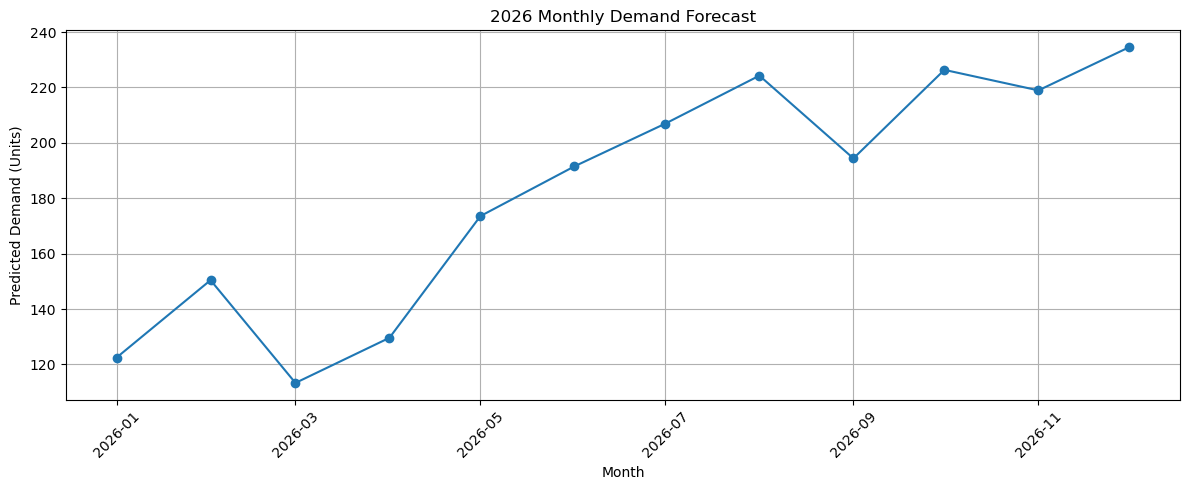

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    demand_forecast["date"],
    demand_forecast["predicted_demand"],
    marker="o"
)

plt.title("2026 Monthly Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Demand (Units)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
demand_forecast.to_csv(
    "../outputs/demand_forecast.csv",
    index=False
)

print("2026 demand forecast saved successfully.")

2026 demand forecast saved successfully.


In [45]:
total_demand_2026 = demand_forecast["predicted_demand"].sum()

highest_demand_month = demand_forecast.loc[
    demand_forecast["predicted_demand"].idxmax()
]

lowest_demand_month = demand_forecast.loc[
    demand_forecast["predicted_demand"].idxmin()
]

print(f"Total predicted demand for 2026: {total_demand_2026:.2f} units")

print(
    f"Highest demand: "
    f"{highest_demand_month['date'].strftime('%B %Y')} "
    f"({highest_demand_month['predicted_demand']:.2f} units)"
)

print(
    f"Lowest demand: "
    f"{lowest_demand_month['date'].strftime('%B %Y')} "
    f"({lowest_demand_month['predicted_demand']:.2f} units)"
)

Total predicted demand for 2026: 2186.23 units
Highest demand: December 2026 (234.55 units)
Lowest demand: March 2026 (113.31 units)
